/Users/shubhamprajapati/Library/Caches/pypoetry/virtualenvs/sahiloan-chatbot-eU83uVND-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-27 11:52:24.400 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:_load_intent_eval_dataset:65 - Looking for eval dataset at: /Users/shubhamprajapati/Desktop/sahiloan/sahiloan-customer-chatbot/data/evals/intent_router.json
2026-01-27 11:52:24.401 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:_load_intent_eval_dataset:78 - Loading 25 eval queries for intent caching...
2026-01-27 11:52:37.851 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:_load_intent_eval_dataset:87 - ✅ Cached 25 intent router embeddings


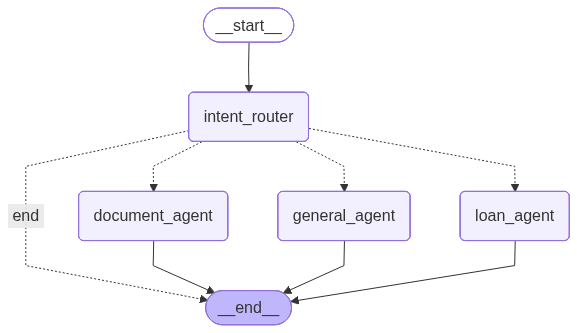

In [1]:
import time
import uuid

from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from opik.integrations.langchain import OpikTracer

from sahiloan_chatbot import logger
from sahiloan_chatbot.application.agent.workflow import ChatState, create_chat_graph

checkpointer = MemorySaver()

graph_builder = create_chat_graph()
graph = graph_builder.compile(checkpointer)
opik_tracer = OpikTracer(graph=graph.get_graph(xray=True), project_name="sahiloan_chatbot")
graph

In [2]:
def get_response(user_query, thread_id=None):
    response = None
    logger.info(f"Agent Started | Query: {user_query}")
    start = time.perf_counter()

    agent_state = ChatState(messages=[HumanMessage(content=user_query)])

    if thread_id is None:
        thread_id = str(uuid.uuid4())[:8]
        logger.info(f"created new thread: {thread_id}")

    logger.info(f"Agent State: {agent_state}")
    config = {"configurable": {"thread_id": str(thread_id)}, "callbacks": [opik_tracer]}
    response = graph.invoke(agent_state, config=config)
    latency = (time.perf_counter() - start) * 1000
    logger.info(f"Agent Completed | Latency: {latency:.2f}ms")
    logger.info(f"Completed State: \n{response}")
    return response.get("messages")[-1].content

In [3]:
get_response("I need car loan instantly")

2026-01-27 11:53:09.039 | INFO     | __main__:get_response:3 - Agent Started | Query: I need car loan instantly
2026-01-27 11:53:09.039 | INFO     | __main__:get_response:10 - created new thread: 55800b81
2026-01-27 11:53:09.039 | INFO     | __main__:get_response:12 - Agent State: {'messages': [HumanMessage(content='I need car loan instantly', additional_kwargs={}, response_metadata={})]}
OPIK: Started logging traces to the "sahiloan_chatbot" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=019bfe1e-c8f2-7df9-b505-dde3e8c6b910&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.
2026-01-27 11:53:09.044 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:150 - intent_router_started
2026-01-27 11:53:09.044 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:154 - intent_router_user_input: I need car loan instantly
2026-01-27 11:53:09.734 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:_find_sim

"I understand that you're looking for an instant car loan. While I don't have specific information on instant loan options, I recommend visiting our website or contacting our customer service team for assistance. They can guide you through the application process and help you find the best loan options available for your needs. If you have any other questions or need further assistance, feel free to ask!"

"I understand that you're looking for an instant car loan. While I don't have specific information on instant loan options, I recommend visiting our website or contacting our customer service team for assistance. They can guide you through the application process and help you find the best loan options available for your needs. If you have any other questions or need further assistance, feel free to ask!"

In [4]:
get_response("which products sahiloan offers?")


2026-01-27 11:54:16.276 | INFO     | __main__:get_response:3 - Agent Started | Query: which products sahiloan offers?
2026-01-27 11:54:16.276 | INFO     | __main__:get_response:10 - created new thread: 153fc890
2026-01-27 11:54:16.277 | INFO     | __main__:get_response:12 - Agent State: {'messages': [HumanMessage(content='which products sahiloan offers?', additional_kwargs={}, response_metadata={})]}
2026-01-27 11:54:16.279 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:150 - intent_router_started
2026-01-27 11:54:16.279 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:154 - intent_router_user_input: which products sahiloan offers?
2026-01-27 11:54:16.786 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:_find_similar_intent:140 - No semantic match | best similarity: 0.6925 (< 0.9)
2026-01-27 11:54:16.787 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:170 - No semantic match, using LLM 

'Sahiloan offers assistance with the following types of loans:\n\n- Home Loans\n- Loan Against Property (LAP)\n- Balance Transfer & Top-Up\n\nWe also have special programs for NRIs, self-employed individuals, and low documentation cases. If you have any specific questions about these products, feel free to ask!'

'Sahiloan offers assistance with the following types of loans:\n\n- Home Loans\n- Loan Against Property (LAP)\n- Balance Transfer & Top-Up\n\nWe also have special programs for NRIs, self-employed individuals, and low documentation cases. If you have any specific questions about these products, feel free to ask!'

In [5]:
get_response("how sahiloan will help me?")


2026-01-27 11:54:59.138 | INFO     | __main__:get_response:3 - Agent Started | Query: how sahiloan will help me?
2026-01-27 11:54:59.138 | INFO     | __main__:get_response:10 - created new thread: 195a695a
2026-01-27 11:54:59.139 | INFO     | __main__:get_response:12 - Agent State: {'messages': [HumanMessage(content='how sahiloan will help me?', additional_kwargs={}, response_metadata={})]}
2026-01-27 11:54:59.142 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:150 - intent_router_started
2026-01-27 11:54:59.142 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:154 - intent_router_user_input: how sahiloan will help me?
2026-01-27 11:54:59.801 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:_find_similar_intent:140 - No semantic match | best similarity: 0.6395 (< 0.9)
2026-01-27 11:54:59.801 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:170 - No semantic match, using LLM for intent clas

'Sahiloan will help you by providing unbiased guidance throughout your loan journey. We assist you in comparing loan offers, verifying if they are genuinely good, and identifying any hidden conditions. Our services include helping you reduce your interest rate, exploring better alternatives, and supporting you even after loan sanction with issues like disbursement delays and EMI-related concerns. Best of all, our services are completely free for borrowers, ensuring that our focus is solely on your financial well-being.'

'Sahiloan will help you by providing unbiased guidance throughout your loan journey. We assist you in comparing loan offers, verifying if they are genuinely good, and identifying any hidden conditions. Our services include helping you reduce your interest rate, exploring better alternatives, and supporting you even after loan sanction with issues like disbursement delays and EMI-related concerns. Best of all, our services are completely free for borrowers, ensuring that our focus is solely on your financial well-being.'

In [7]:
get_response("What's the current interest rate for my Home loans?")

2026-01-27 11:56:16.887 | INFO     | __main__:get_response:3 - Agent Started | Query: What's the current interest rate for my Home loans?
2026-01-27 11:56:16.888 | INFO     | __main__:get_response:10 - created new thread: a10cbf01
2026-01-27 11:56:16.888 | INFO     | __main__:get_response:12 - Agent State: {'messages': [HumanMessage(content="What's the current interest rate for my Home loans?", additional_kwargs={}, response_metadata={})]}
2026-01-27 11:56:16.892 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:150 - intent_router_started
2026-01-27 11:56:16.892 | DEBUG    | sahiloan_chatbot.application.agent.workflow.nodes:intent_router:154 - intent_router_user_input: What's the current interest rate for my Home loans?
2026-01-27 11:56:17.327 | INFO     | sahiloan_chatbot.application.agent.workflow.nodes:_find_similar_intent:134 - Semantic match found | similarity: 0.9316 | matched: 'What the current interest rate for my home loan?' | route: loan_agent
2026

"What's the current interest rate for my Home loans?"

In [ ]:
from sahiloan_chatbot.application.chat_service.workflow.graph import create_intent_router_graph
from sahiloan_chatbot.application.chat_service.workflow.state import ChatState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
from opik.integrations.langchain import OpikTracer
import uuid
import time

# Initialize memory checkpointer
checkpointer = MemorySaver()

# Create and compile the intent router graph
graph_builder = create_intent_router_graph()
intent_router_graph = graph_builder.compile(checkpointer)

# Initialize Opik tracer
opik_tracer = OpikTracer(graph=intent_router_graph.get_graph(xray=True), project_name="sahiloan_chatbot")

print("✅ Intent router graph compiled successfully")
print(f"✅ Opik tracer initialized")

# Display the graph
intent_router_graph

In [ ]:
from langgraph.types import Command
from sahiloan_chatbot import logger


def get_intent_router_response(user_query, thread_id=None):
    response = None
    logger.info(f"Agent Started | Query: {user_query}")
    start = time.perf_counter()

    agent_state = ChatState(messages=[HumanMessage(content=user_query)])

    if thread_id is None:
        thread_id = str(uuid.uuid4())[:8]
        logger.info(f"created new thread: {thread_id}")

    logger.info(f"Agent State: {agent_state}")
    config = {"configurable": {"thread_id": str(thread_id)}, "callbacks": [opik_tracer]}
    response = intent_router_graph.invoke(agent_state, config=config)
    latency = (time.perf_counter() - start) * 1000
    logger.info(f"Agent Completed | Latency: {latency:.2f}ms")
    logger.info(f"Completed State: \n{response}")
    return response.get("route_to")

In [ ]:
get_intent_router_response("who is shubham")